In [ ]:
import os, json
os.makedirs("/root/.kaggle", exist_ok=True)

kaggle_credentials = {
    "username": "your kaggle username",
    "key": "your kaggle key"
}
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_credentials, f)
os.chmod("/root/.kaggle/kaggle.json", 0o600)

!kaggle datasets download -d abdallahalidev/plantvillage-dataset
import zipfile
with zipfile.ZipFile("plantvillage-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("plantvillage")
print("Dataset ready!")

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:10<00:00, 200MB/s]

Dataset ready!


In [2]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.utils.data import DataLoader, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
base_path = "plantvillage/plantvillage dataset/color"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

dataset = datasets.ImageFolder(base_path, transform=transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 1358 | Val batches: 340


In [4]:
model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

model.classifier[1] = nn.Linear(in_features=1280, out_features=38)

for param in model.parameters():
    param.requires_grad = False
for param in model.classifier.parameters():
    param.requires_grad = True

model = model.to(device)
print(f"Model ready on: {device}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 79.5MB/s]


Model ready on: cpu
Trainable params: 48,678


In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [6]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), 100. * correct / total

In [7]:
def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), 100. * correct / total

In [9]:
# Results from day6 training — no need to retrain!
history = {
    "train_loss": [0.5406, 0.2111, 0.1700],
    "val_loss":   [0.1810, 0.1325, 0.1162],
    "train_acc":  [87.68, 94.06, 94.90],
    "val_acc":    [95.62, 96.15, 96.62]
}

NUM_EPOCHS = 3
print("History loaded from day6 results!")

History loaded from day6 results!


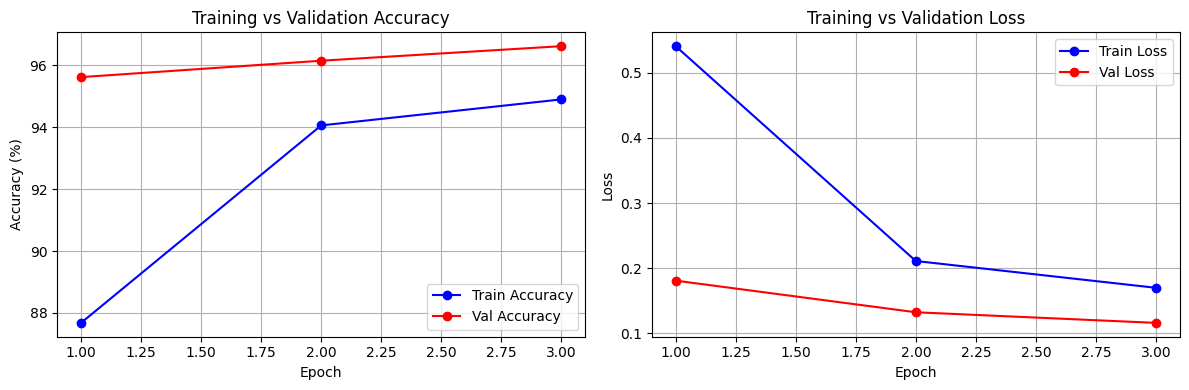

Plot saved as accuracy_curves.png


In [10]:
import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# --- Left plot: Accuracy ---
ax1.plot(epochs, history["train_acc"], "b-o", label="Train Accuracy")
ax1.plot(epochs, history["val_acc"],   "r-o", label="Val Accuracy")
ax1.set_title("Training vs Validation Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy (%)")
ax1.legend()
ax1.grid(True)

# --- Right plot: Loss ---
ax2.plot(epochs, history["train_loss"], "b-o", label="Train Loss")
ax2.plot(epochs, history["val_loss"],   "r-o", label="Val Loss")
ax2.set_title("Training vs Validation Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig("accuracy_curves.png", dpi=150)
plt.show()
print("Plot saved as accuracy_curves.png")